we will install the required libararies

In [ ]:
!pip install tensorflow keras

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.datasets import cifar10
import numpy as np
import random as rand
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Load the dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


print the shape of dataset, calculate the number of classes and what are they

In [ ]:
print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

num_clases=np.unique(y_train)
print('number of classes: ', num_clases)

x_train shape:  (50000, 32, 32, 3)
x_test shape:  (10000, 32, 32, 3)
y_train shape:  (50000, 1)
y_test shape:  (10000, 1)
number of classes:  [0 1 2 3 4 5 6 7 8 9]


checking the rgb vales so that we can convert it to 0-1 values for better training of data and reducing the larger values for better dense layer training

In [ ]:
print(x_train[1, :])

#converting values 0-1
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

#checking the updated values
print(x_train[1, :])

[[[154 177 187]
  [126 137 136]
  [105 104  95]
  ...
  [ 91  95  71]
  [ 87  90  71]
  [ 79  81  70]]

 [[140 160 169]
  [145 153 154]
  [125 125 118]
  ...
  [ 96  99  78]
  [ 77  80  62]
  [ 71  73  61]]

 [[140 155 164]
  [139 146 149]
  [115 115 112]
  ...
  [ 79  82  64]
  [ 68  70  55]
  [ 67  69  55]]

 ...

 [[175 167 166]
  [156 154 160]
  [154 160 170]
  ...
  [ 42  34  36]
  [ 61  53  57]
  [ 93  83  91]]

 [[165 154 128]
  [156 152 130]
  [159 161 142]
  ...
  [103  93  96]
  [123 114 120]
  [131 121 131]]

 [[163 148 120]
  [158 148 122]
  [163 156 133]
  ...
  [143 133 139]
  [143 134 142]
  [143 133 144]]]
[[[0.6039216  0.69411767 0.73333335]
  [0.49411765 0.5372549  0.53333336]
  [0.4117647  0.40784314 0.37254903]
  ...
  [0.35686275 0.37254903 0.2784314 ]
  [0.34117648 0.3529412  0.2784314 ]
  [0.30980393 0.31764707 0.27450982]]

 [[0.54901963 0.627451   0.6627451 ]
  [0.5686275  0.6        0.6039216 ]
  [0.49019608 0.49019608 0.4627451 ]
  ...
  [0.3764706  0.3882353

let's check our one of the image

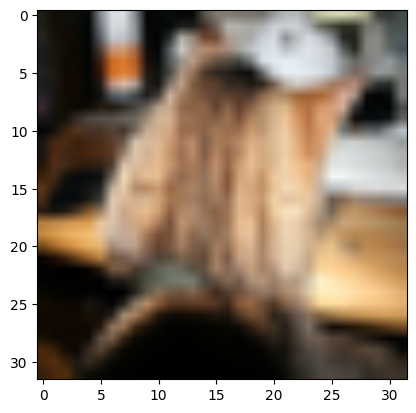

In [ ]:
random_id=rand.randint(0,len(x_train))
plt.imshow(x_train[random_id, :], interpolation='bilinear')
plt.show()

now we will design our model convolutional layer and max pooling layer
we use sequential model as ouer layers will be stagged up in a sequence

1. we will identify how many filers do we need to use: it is done generally by following 'doubling patern' or 'power of 2', we gradually increase the number of filer with each convolutional layer to identify more details in the image.

2. we will identify the size of filter by just taking care it's a odd dimension as it prevents spatial distortion when padding

In [ ]:
model = Sequential([
          Conv2D(32, (3, 3), activation='relu'),
          MaxPooling2D((2, 2)),

          Conv2D(64, (3, 3), activation='relu'),
          MaxPooling2D((2, 2)),

          Flatten(),
          Dense(64, activation='relu'),
          Dense(10, activation='softmax')
    ])
#we compile the sequential model with our loss function, optimizer, accuracy
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

now we train the model using fit function where we define the batch_size, epochs(no.of.times this deep nural netwroek run in a loop) and the dataset to train on and the test data as validation data

In [ ]:
model.fit(x_train, y_train, batch_size=64, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.4480 - loss: 1.5312 - val_accuracy: 0.5604 - val_loss: 1.2707
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.5789 - loss: 1.1983 - val_accuracy: 0.6019 - val_loss: 1.1422
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - accuracy: 0.6334 - loss: 1.0500 - val_accuracy: 0.6461 - val_loss: 1.0275
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 88ms/step - accuracy: 0.6661 - loss: 0.9579 - val_accuracy: 0.6572 - val_loss: 0.9839
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.6892 - loss: 0.8951 - val_accuracy: 0.6733 - val_loss: 0.9429
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.7095 - loss: 0.8419 - val_accuracy: 0.6816 - val_loss: 0.9183
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.7256 - loss: 0.7945 - val_accuracy: 0.6851 - val_loss: 0.9239
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.7396 - loss: 0.7523 

now we evaluate the data

In [ ]:
loss, accuracy =model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.3f}")
print(f"Test Accuracy: {accuracy:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6935 - loss: 0.9062
Test Loss: 0.906
Test Accuracy: 0.693


now we prdict the outputs and make confussion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


<Figure size 1000x800 with 0 Axes>

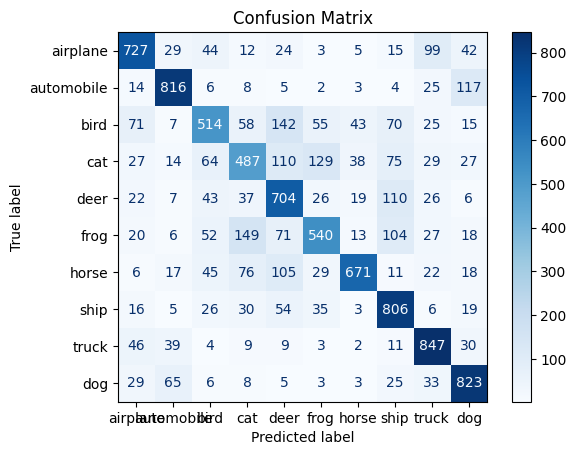

In [ ]:
# Get predictions for the test set
y_pred_probabilities = model.predict(x_test)
# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probabilities, axis=1)
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['airplane', 'automobile', 'bird', 'cat', 'deer', 'frog', 'horse', 'ship', 'truck', 'dog'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


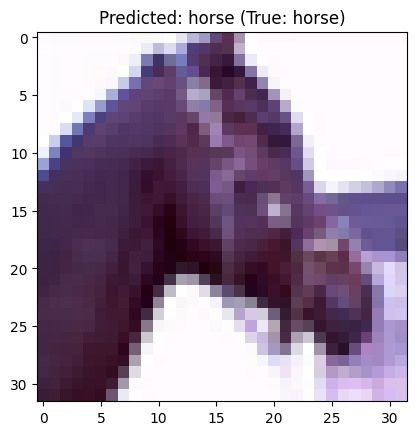

In [ ]:

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Get a random index from the test set
random_id = rand.randint(0, len(x_test) - 1)

# Get the image and its true label
image_to_predict = x_test[random_id]
true_label = y_test[random_id][0]

# Reshape the image for prediction (model expects a batch dimension)
image_for_prediction = np.expand_dims(image_to_predict, axis=0)

# Get the model's prediction
predictions = model.predict(image_for_prediction)
predicted_label_index = np.argmax(predictions)
predicted_label_name = class_names[predicted_label_index]

# Display the image and its predicted label
plt.imshow(image_to_predict)
plt.title(f"Predicted: {predicted_label_name} (True: {class_names[true_label]})")
plt.show()

In [ ]:
print(y_test)

[[3]
 [8]
 [8]
 ...
 [5]
 [1]
 [7]]
